TASK 1

In [1]:
import pandas as pd
import time

df = pd.read_csv("athlete_events.csv").sample(n=50_000, random_state=42)
df.to_csv("athlete_events_sample.csv",index=False)
print(df.shape)
df.head()



df = df.dropna(subset=["ID", "Year", "Weight"])
df["ID"] = df["ID"].astype(int)
df["Year"] = df["Year"].astype(int)
df["Weight"] = df["Weight"].astype(float)

print(df.shape)

(50000, 15)
(38333, 15)


TASK 1, PART 1

In [2]:
#Linear search
def linear_search(arr, key):
    for item in arr:
        if item == key:
            return item
    return None


#Binary Search
def binary_search(arr, key):
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == key:
            return arr[mid]
        elif arr[mid] < key:
            left = mid + 1
        else:
            right = mid - 1
    return None


#Jump Search
import math

def jump_search(arr, key):
    n = len(arr)
    step = int(math.sqrt(n))
    prev = 0
    
    while arr[min(step, n)-1] < key:
        prev = step
        step += int(math.sqrt(n))
        if prev >= n:
            return None
    
    for i in range(prev, min(step, n)):
        if arr[i] == key:
            return arr[i]
    
    return None


#Interpolation Search
def interpolation_search(arr, key):
    low, high = 0, len(arr) - 1
    
    while low <= high and arr[low] <= key <= arr[high]:
        if arr[high] == arr[low]:
            if arr[low] == key:
                return arr[low]
            return None
        
        pos = low + int(((high - low) / (arr[high] - arr[low])) * (key - arr[low]))
        
        if arr[pos] == key:
            return arr[pos]
        elif arr[pos] < key:
            low = pos + 1
        else:
            high = pos - 1
    
    return None


TASK 1, PART 2

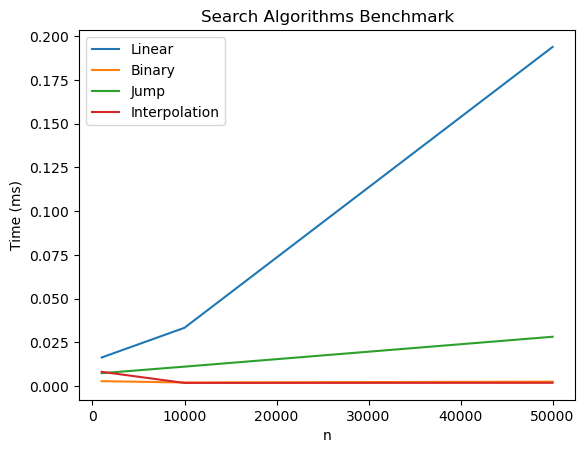

In [3]:
import matplotlib.pyplot as plt

sizes = [1000, 10000, 50000]

results = {
    "Linear": [],
    "Binary": [],
    "Jump": [],
    "Interpolation": []
}

for n in sizes:
    sample = df["ID"].head(n).tolist()
    sample_sorted = sorted(sample)
    key = sample_sorted[n // 2]
    
    # Linear
    times = []
    for _ in range(3):
        start = time.perf_counter()
        linear_search(sample, key)
        times.append((time.perf_counter() - start) * 1000)
    results["Linear"].append(sum(times)/3)
    
    # Binary
    times = []
    for _ in range(3):
        start = time.perf_counter()
        binary_search(sample_sorted, key)
        times.append((time.perf_counter() - start) * 1000)
    results["Binary"].append(sum(times)/3)
    
    # Jump
    times = []
    for _ in range(3):
        start = time.perf_counter()
        jump_search(sample_sorted, key)
        times.append((time.perf_counter() - start) * 1000)
    results["Jump"].append(sum(times)/3)
    
    # Interpolation
    times = []
    for _ in range(3):
        start = time.perf_counter()
        interpolation_search(sample_sorted, key)
        times.append((time.perf_counter() - start) * 1000)
    results["Interpolation"].append(sum(times)/3)

# Plot
for name, vals in results.items():
    plt.plot(sizes, vals, label=name)

plt.xlabel("n")
plt.ylabel("Time (ms)")
plt.title("Search Algorithms Benchmark")
plt.legend()
plt.show()

TASK 1, PART 3

Binary search wins for large datasets because it reduces the search space logarithmically. 
Interpolation search can perform worse than binary search when the data is not uniformly distributed.
Example worst case:
arr = [1, 2, 3, 4, 5, 1000000]
Here interpolation jumps badly due to uneven distribution, making it slower than binary search.

TASK 2, PART 1

In [4]:
class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None


from collections import deque

#node klase
class Node:
    def __init__(self, key, value):
        self.key = key
        self.values = [value] #tam paciam key  
        self.left = None
        self.right = None



class BinarySearchTree:
    def __init__(self):
        self.root = None

    
    def insert(self, key, value):
        def _insert(node, key, value):
            if node is None:
                return Node(key, value)
            
            if key == node.key:
                node.values.append(value) 
            elif key < node.key:
                node.left = _insert(node.left, key, value)
            else:
                node.right = _insert(node.right, key, value)
            
            return node
        
        self.root = _insert(self.root, key, value)


    def search(self, key):
        node = self.root
        while node:
            if key == node.key:
                return node.values
            elif key < node.key:
                node = node.left
            else:
                node = node.right
        return None


    def delete(self, key):
        def _min_value_node(node):
            current = node
            while current.left:
                current = current.left
            return current

        def _delete(node, key):
            if not node:
                return None
            
            if key < node.key:
                node.left = _delete(node.left, key)
            elif key > node.key:
                node.right = _delete(node.right, key)
            else:
            
                if not node.left and not node.right:
                    return None
                
            
                if not node.left:
                    return node.right
                if not node.right:
                    return node.left
                
              
                temp = _min_value_node(node.right)
                node.key = temp.key
                node.values = temp.values
                node.right = _delete(node.right, temp.key)
            
            return node
        
        self.root = _delete(self.root, key)


    def inorder(self):
        result = []
        def _in(node):
            if node:
                _in(node.left)
                result.extend(node.values)
                _in(node.right)
        _in(self.root)
        return result


    def preorder(self):
        result = []
        def _pre(node):
            if node:
                result.extend(node.values)
                _pre(node.left)
                _pre(node.right)
        _pre(self.root)
        return result


    def postorder(self):
        result = []
        def _post(node):
            if node:
                _post(node.left)
                _post(node.right)
                result.extend(node.values)
        _post(self.root)
        return result


    def bfs(self):
        result = []
        q = deque([self.root])
        
        while q:
            node = q.popleft()
            if node:
                result.extend(node.values)
                q.append(node.left)
                q.append(node.right)
        
        return result


    def range_query(self, low, high):
        result = []
        
        def _range(node):
            if not node:
                return
            
            if node.key > low:
                _range(node.left)
            
            if low <= node.key <= high:
                result.extend(node.values)
            
            if node.key < high:
                _range(node.right)
        
        _range(self.root)
        return result
    
df = df.sample(frac=1, random_state=42)


TASK 2, PART 2

In [5]:
bst = BinarySearchTree()

for _, row in df.iterrows():
    bst.insert(row["Year"], row.to_dict())


low, high = 2000, 2010

start = time.perf_counter()
res_bst = bst.range_query(low, high)
bst_time = (time.perf_counter() - start) * 1000

start = time.perf_counter()
res_naive = df[(df["Year"] >= low) & (df["Year"] <= high)].to_dict("records")
naive_time = (time.perf_counter() - start) * 1000

print("BST time (ms):", bst_time)
print("Naive time (ms):", naive_time)
print("Results count:", len(res_bst)) 

BST time (ms): 0.1772999530658126
Naive time (ms): 62.053399975411594
Results count: 9891


TASK 3, PART 1

In [6]:
class MinHeap:
    def __init__(self):
        self.heap = []
    
    def insert(self, val):
        self.heap.append(val)
        self._up(len(self.heap)-1)
    
    def _up(self, i):
        while i > 0:
            parent = (i-1)//2
            if self.heap[i] < self.heap[parent]:
                self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
                i = parent
            else:
                break
    
    def extract(self):
        if not self.heap:
            return None
        self.heap[0], self.heap[-1] = self.heap[-1], self.heap[0]
        val = self.heap.pop()
        self._down(0)
        return val
    
    def _down(self, i):
        n = len(self.heap)
        while True:
            smallest = i
            left = 2*i + 1
            right = 2*i + 2
            
            if left < n and self.heap[left] < self.heap[smallest]:
                smallest = left
            if right < n and self.heap[right] < self.heap[smallest]:
                smallest = right
            
            if smallest != i:
                self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
                i = smallest
            else:
                break
    
    def peek(self):
        return self.heap[0] if self.heap else None
    

TASK 3, PART 2

In [7]:
heap = MinHeap()
k = 10

import time

start = time.perf_counter()

for _, row in df.iterrows():
    val = row["Weight"]
    
    if len(heap.heap) < k:
        heap.insert(val)
    elif val > heap.peek():
        heap.extract()
        heap.insert(val)

heap_time = (time.perf_counter() - start) * 1000

start = time.perf_counter()
top_naive = sorted(df["Weight"], reverse=True)[:10]
naive_time = (time.perf_counter() - start) * 1000

print("Heap time:", heap_time)
print("Naive time:", naive_time)
print("Top-10 weights:", sorted(heap.heap, reverse=True))


Heap time: 1016.9838000438176
Naive time: 6.011800025589764
Top-10 weights: [190.0, 182.0, 175.0, 170.0, 165.0, 165.0, 163.0, 161.0, 160.0, 158.0]


A heap is ideal for top-k because it keeps only the best k elements and updates efficiently in O(log k). 
However, it is poor for finding a specific element because it does not maintain full order, so searching requires O(n).

TASK 4, PART 1

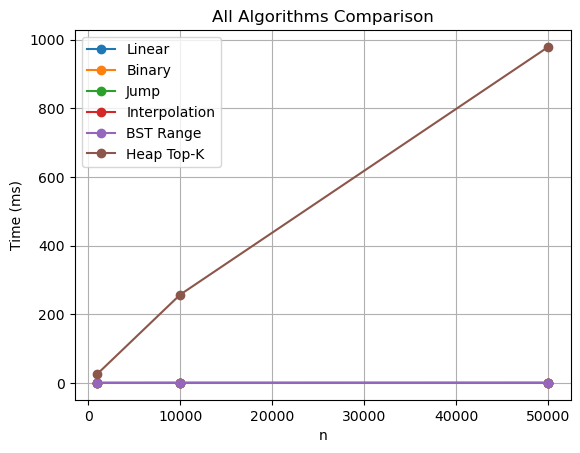

In [10]:
sizes = [1000, 10000, 50000]

results = {
    "Linear": [],
    "Binary": [],
    "Jump": [],
    "Interpolation": [],
    "BST Range": [],
    "Heap Top-K": []
}

for n in sizes:
    df_n = df.head(n).copy()
    
    
    arr = df_n["ID"].tolist()
    arr_sorted = sorted(arr)
    key = arr_sorted[len(arr_sorted)//2]
    
    #Linear ----
    times = []
    for _ in range(3):
        start = time.perf_counter()
        linear_search(arr, key)
        times.append((time.perf_counter() - start)*1000)
    results["Linear"].append(sum(times)/3)
    
    #Binary ----
    times = []
    for _ in range(3):
        start = time.perf_counter()
        binary_search(arr_sorted, key)
        times.append((time.perf_counter() - start)*1000)
    results["Binary"].append(sum(times)/3)
    
    #Jump ----
    times = []
    for _ in range(3):
        start = time.perf_counter()
        jump_search(arr_sorted, key)
        times.append((time.perf_counter() - start)*1000)
    results["Jump"].append(sum(times)/3)
    
    #Interpolation ----
    times = []
    for _ in range(3):
        start = time.perf_counter()
        interpolation_search(arr_sorted, key)
        times.append((time.perf_counter() - start)*1000)
    results["Interpolation"].append(sum(times)/3)
    
    
    #BST
    bst = BinarySearchTree()
    
    df_shuffled = df_n.sample(frac=1, random_state=42)
    
    for _, row in df_shuffled.iterrows():
        bst.insert(row["Year"], row.to_dict())
    
    low, high = 2000, 2010
    
    start = time.perf_counter()
    bst.range_query(low, high)
    bst_time = (time.perf_counter() - start) * 1000
    
    results["BST Range"].append(bst_time)
    
    
    #HEAP
    heap = MinHeap()
    k = 10
    
    start = time.perf_counter()
    
    for _, row in df_n.iterrows():
        val = row["Weight"]
        
        if len(heap.heap) < k:
            heap.insert(val)
        elif val > heap.peek():
            heap.extract()
            heap.insert(val)
    
    heap_time = (time.perf_counter() - start) * 1000
    
    results["Heap Top-K"].append(heap_time)

for name, vals in results.items():
    plt.plot(sizes, vals, marker='o', label=name)

plt.xlabel("n")
plt.ylabel("Time (ms)")
plt.title("All Algorithms Comparison")
plt.legend()
plt.grid()
plt.show()




TASK 4, PART 2

When inserting sorted values (1, 2, 3, ..., 1000), the BST becomes completely unbalanced and behaves like a linked list.
This causes the recursion depth to grow linearly with n, eventually exceeding Python's recursion limit and resulting in a RecursionError.
A better tree would maintain balance (e.g., AVL or Red-Black tree), ensuring logarithmic height and avoiding this issue.